## Authors
- David Robredo Manuel
- Duarte Novas Álvarez
- Rubén González Braña

## Imports

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from os import listdir
from os.path import isfile, join

## Loading data

In [8]:
path = "./histories/"
history_dataframes = [
    (pd.read_csv(join(path, f), index_col=0), f) 
    for f in listdir(path) if isfile(join(path, f))
]

## Comparison

Loading the data (results taken from `generateAmazonDataset.ipynb`)

In [2]:
metrics = {
    "model1": {"loss":0.2891, "accuracy":0.8812},
    "model2": {"loss":0.2989, "accuracy":0.8758},
    "model3": {"loss":0.2959, "accuracy":0.8913},
    "model4": {"loss":0.3054, "accuracy":0.8824},
    "model5": {"loss":0.2707, "accuracy":0.8916},
}

#### Loss Comparison

For this comparison we'll be plotting the loss values in the testing phase of the models

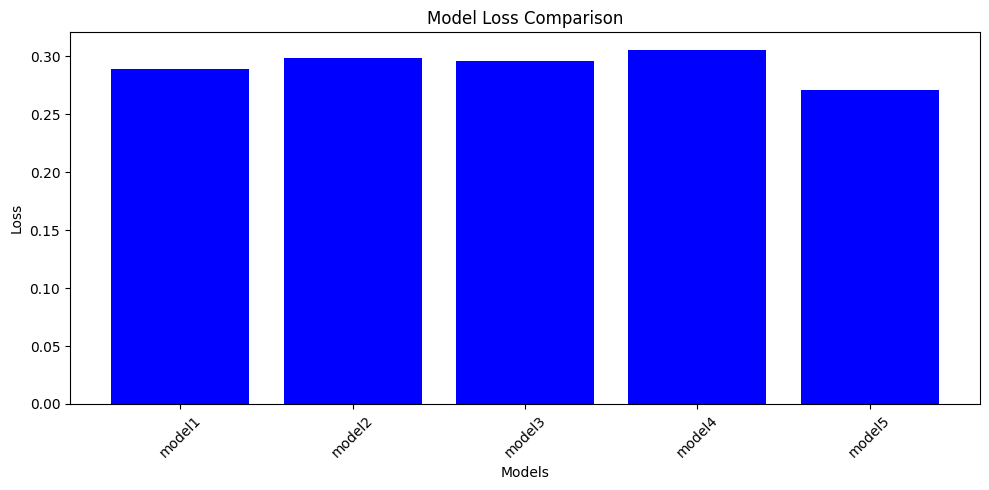

In [3]:
plt.figure(figsize=(10, 5))
plt.bar(metrics.keys(), [metrics[model]["loss"] for model in metrics.keys()], color='blue')
plt.title('Model Loss Comparison')
plt.xlabel('Models')
plt.ylabel('Loss')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As it can be seen, model 5 has the lowest test loss among all models. Its architecture combines 1 embedding, 2 convolutional, 2 max pooling, 1 bidirectional lstm and a dropout layer. It is a very complex architecture, but it seems that it adapts better than simpler ones.

#### Accuracy Comparison

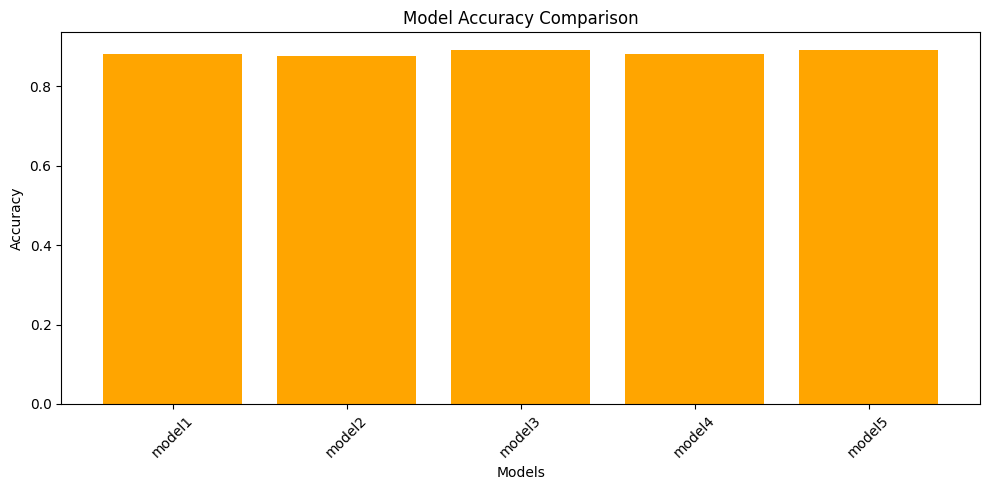

In [4]:
plt.figure(figsize=(10, 5))
plt.bar(metrics.keys(), [metrics[model]["accuracy"] for model in metrics.keys()], color='orange')
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In terms of accuracy, the models 5 is still in the top, although the model 3 is very close to it. With a much simpler architecture (1 bidirectional GRU, 1 embedding and 1 dropout layer), it attains almost the same accuracy on the test set than a more complex architecture.

#### Accuracy & Loss Comparison

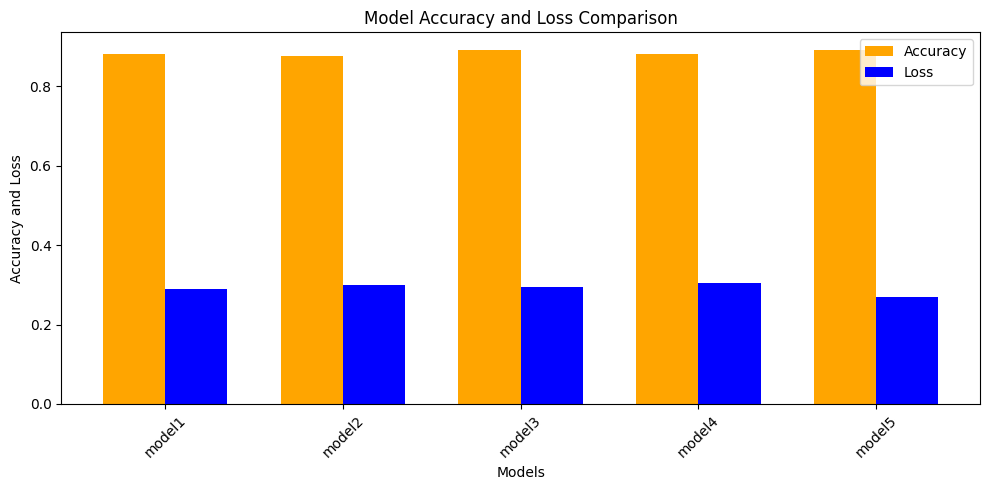

In [5]:
models = list(metrics.keys())
mae_values = [metrics[model]['accuracy'] for model in models]
loss_values = [metrics[model]['loss'] for model in models]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, mae_values, width, color='orange', label='Accuracy')
plt.bar(x + width/2, loss_values, width, color='blue', label='Loss')

plt.title('Model Accuracy and Loss Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy and Loss')
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Overall, it is sure to think that model 5 has a better perfomance, being the model with the lowset test loss and the highest test accuracy. Nevertheless, the rest of the models do not fall very far from it, meaning that these architectures are good approaches for this problem.

### Validation accuracy during training

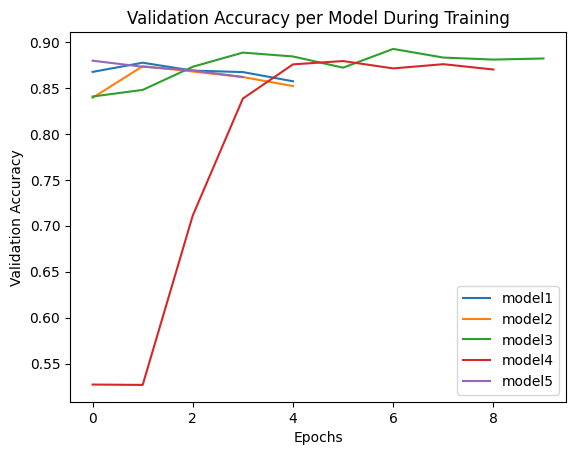

In [17]:
for i, data in enumerate(history_dataframes):
    df = data[0]
    model_name = data[1].split('.',1)[0].split('_')[2:]
    model_name = ''.join(model_name)
    plt.plot(range(len(df.index)), df['val_accuracy'], label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title(f"Validation Accuracy per Model During Training")
plt.legend()
plt.show()

As it can be seen in the models training history, models 1,2 and 5 converge faster than the rest, but models 4 and 3, even though they converge later, they obtain a little better performance.

### Validation loss during training

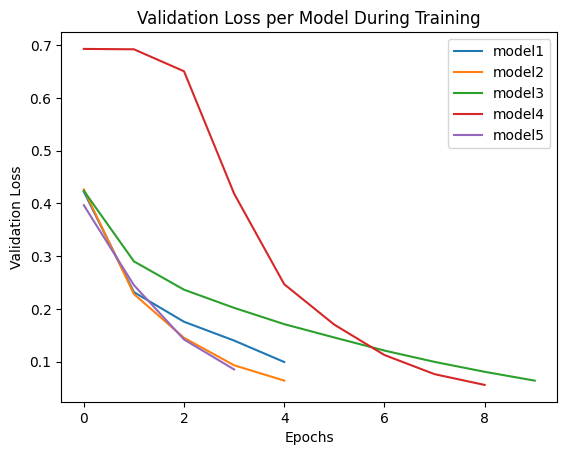

In [18]:
for i, data in enumerate(history_dataframes):
    df = data[0]
    model_name = data[1].split('.',1)[0].split('_')[2:]
    model_name = ''.join(model_name)
    plt.plot(range(len(df.index)), df['loss'], label=model_name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title(f"Validation Loss per Model During Training")
plt.legend()
plt.show()

As in the previous plot, here models 1,2 and 5 converge faster, but model 3 and 4 finish training with a lower validation loss.

#### Conclusions

In summary, after evaluating different architectures on the Amazon dataset, it is clear that the fifth model, with the following architecure:  

| Layer (type)             | Output Shape          | Param #     |
|--------------------------|------------------------|-------------|
| embedding_4 (Embedding)  | (None, 166, 128)       | 1,280,000   |
| conv1d (Conv1D)          | (None, 164, 128)       | 49,280      |
| max_pooling1d (MaxPooling1D) | (None, 82, 128)   | 0           |
| conv1d_1 (Conv1D)        | (None, 80, 128)        | 49,280      |
| max_pooling1d_1 (MaxPooling1D) | (None, 40, 128) | 0           |
| bidirectional_5 (Bidirectional) | (None, 256)    | 263,168     |
| dropout_3 (Dropout)      | (None, 256)            | 0           |
| dense_4 (Dense)          | (None, 1)              | 257         |



It achieved the best performance with the highest test accuracy of **89,16%**. This result surpassed the established threshold of 84%.

It is important to remark that all models are above the established threshold, meaning that all architectures are good options to solve the problem.